In [2]:
import os

# 1. إعداد التوكن مباشرة
os.environ['KAGGLE_USERNAME'] = "AbdelrhmanNOD" # اسم المستخدم بتاعك (موجود في بروفايلك)
os.environ['KAGGLE_KEY'] = "KGAT_0c93d5a33bef5ddf28b93ac31f7f68ee" # الكود اللي ظهرلك في الصورة

# 2. تحميل الداتا مباشرة
!kaggle datasets download -d kapillondhe/american-sign-language

# 3. فك الضغط في فولدر اسمه dataset
!unzip -q american-sign-language.zip -d ./dataset

Dataset URL: https://www.kaggle.com/datasets/kapillondhe/american-sign-language
License(s): GPL-2.0
100% 4.64G/4.64G [00:41<00:00, 119MB/s]



In [14]:
import os

# المسار المتوقع بعد فك الضغط
base_path = './dataset/ASL_Dataset'

if os.path.exists(base_path):
    print("✅ تمام جداً، المجلد موجود دلوقتي")
    print(f"📂 المجلدات الفرعية: {os.listdir(base_path)}")
else:
    # لو لسه مش موجود، كود البحث ده هيقولنا هو فين بالضبط
    print("⚠️ المجلد مش في المسار المباشر، جاري البحث عنه...")
    for root, dirs, files in os.walk('./dataset'):
        if 'ASL_Dataset' in dirs:
            base_path = os.path.join(root, 'ASL_Dataset')
            print(f"✅ لقيته! المسار الصحيح هو: {base_path}")
            break

✅ تمام جداً، المجلد موجود دلوقتي
📂 المجلدات الفرعية: ['Test', 'Train']


In [15]:
import cv2
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

# دالة محسنة لتقليل الضغط على الرام
def load_data_optimized(folder_path, img_size=96, max_per_class=300):
    images = []
    labels = []
    for class_name in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_path): continue
        count = 0
        for img_name in os.listdir(class_path):
            if count >= max_per_class: break
            img = cv2.imread(os.path.join(class_path, img_name))
            if img is None: continue

            # التحويل لـ RGB وتصغير الحجم لـ 96
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))

            # تحويل لنوع بيانات أخف وتقسيم على 255 مباشرة لتوفير الرام
            images.append(img.astype('float32') / 255.0)
            labels.append(class_name)
            count += 1
    return np.array(images), np.array(labels)

print("⏳ جاري تحميل البيانات بشكل محسن لتوفير الذاكرة...")
X_train_pre, y_train_pre = load_data_optimized('./dataset/ASL_Dataset/Train')
X_test_pre, y_test_pre = load_data_optimized('./dataset/ASL_Dataset/Test')

# الترميز والبعثرة
le = LabelEncoder()
y_train_idx = le.fit_transform(y_train_pre)
y_test_idx = le.transform(y_test_pre)
X_train_pre, y_train_idx = shuffle(X_train_pre, y_train_idx, random_state=42)

print(f"✅ تم التحميل بنجاح! إجمالي صور التدريب الآن: {len(X_train_pre)}")

⏳ جاري تحميل البيانات بشكل محسن لتوفير الذاكرة...
✅ تم التحميل بنجاح! إجمالي صور التدريب الآن: 8400


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# 1. تقسيم البيانات لتدريب وتحقق (80% تدريب، 20% تحقق)
X_train_aug, X_val_aug, y_train_aug, y_val_aug = train_test_split(
    X_train_pre, y_train_idx, test_size=0.2, random_state=42, stratify=y_train_idx
)

# 2. إعداد مولد الصور (الـ Augmentation)
datagen = ImageDataGenerator(
    rotation_range=10,      # ميلان بسيط
    zoom_range=0.1,         # تكبير بسيط
    width_shift_range=0.1,  # إزاحة
    height_shift_range=0.1,
    horizontal_flip=False   # مهم جداً: تعطيل الانعكاس في لغة الإشارة
)

# التأكد من جاهزية المولد
datagen.fit(X_train_aug)

In [17]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# لاحظ تغيير الـ input_shape لـ 96
base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
for layer in base_model_vgg.layers:
    layer.trainable = False

x = base_model_vgg.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions_vgg = Dense(len(le.classes_), activation='softmax')(x)

model_vgg = Model(inputs=base_model_vgg.input, outputs=predictions_vgg)
model_vgg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# التدريب
print("⏳ جاري تدريب VGG16 مع تقنية Data Augmentation...")
history_vgg = model_vgg.fit(
    datagen.flow(X_train_aug, y_train_aug, batch_size=32),
    epochs=5,
    validation_data=(X_val_aug, y_val_aug) # بيانات التحقق ثابتة بدون تعديل
)

⏳ جاري تدريب VGG16 مع تقنية Data Augmentation...
Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - accuracy: 0.5121 - loss: 1.9924 - val_accuracy: 0.9446 - val_loss: 0.7261
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 25s 119ms/step - accuracy: 0.8417 - loss: 0.6996 - val_accuracy: 0.9690 - val_loss: 0.2862
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 24s 114ms/step - accuracy: 0.9129 - loss: 0.3859 - val_accuracy: 0.9839 - val_loss: 0.1485
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - accuracy: 0.9396 - loss: 0.2634 - val_accuracy: 0.9911 - val_loss: 0.0950
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - accuracy: 0.9540 - loss: 0.1986 - val_accuracy: 0.9976 - val_loss: 0.0672


In [19]:
# التوقع باستخدام VGG16 المذرب مع Augmentation
y_pred_vgg = model_vgg.predict(X_test_pre)
y_pred_classes_vgg = np.argmax(y_pred_vgg, axis=1)

from sklearn.metrics import classification_report
print("📊 تقرير أداء VGG16 (مع Data Augmentation):")
print(classification_report(y_test_idx, y_pred_classes_vgg, target_names=le.classes_))

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 607ms/step
📊 تقرير أداء VGG16 (مع Data Augmentation):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         4
           C       1.00      1.00      1.00         4
           D       1.00      1.00      1.00         4
           E       1.00      1.00      1.00         4
           F       1.00      1.00      1.00         4
           G       1.00      1.00      1.00         4
           H       1.00      1.00      1.00         4
           I       1.00      1.00      1.00         4
           J       1.00      1.00      1.00         4
           K       1.00      1.00      1.00         4
           L       1.00      1.00      1.00         4
           M       1.00      1.00      1.00         4
           N       1.00      1.00      1.00         4
     Nothing       1.00      1.00      1.00         4
           O       1.00      1.00      1.00         4

In [25]:
# =========================================================
# المرحلة الثانية: الضبط الدقيق (Fine-tuning) لنموذج VGG16
# الهدف: السماح لآخر طبقات النموذج بالتكيف مع تفاصيل لغة الإشارة
# =========================================================

# 1. إلغاء تجميد النموذج الأساسي بالكامل أولاً
base_model_vgg.trainable = True

# 2. تجميد كل الطبقات ما عدا آخر 4 طبقات (الطبقات العليا التي تدرك الأنماط المعقدة)
for layer in base_model_vgg.layers[:-4]:
    layer.trainable = False

# 3. إعادة تجميع النموذج بمعدل تعلم منخفض جداً (Learning Rate = 0.00001)
# نستخدم معدل تعلم صغير لكي لا ندمر الأوزان التي تعلمها النموذج مسبقاً من ImageNet
from tensorflow.keras.optimizers import Adam
model_vgg.compile(optimizer=Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. إعادة التدريب باستخدام نفس البيانات المعززة والمفصوله سابقاً
print("⏳ جاري تنفيذ الـ Fine-tuning لنموذج VGG16...")
history_vgg_fine = model_vgg.fit(
    datagen.flow(X_train_aug, y_train_aug, batch_size=32),
    epochs=2,
    validation_data=(X_val_aug, y_val_aug) # استخدام نفس بيانات التحقق
)

print("✅ انتهت عملية الـ Fine-tuning بنجاح!")

⏳ جاري تنفيذ الـ Fine-tuning لنموذج VGG16...
Epoch 1/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - accuracy: 0.9680 - loss: 0.1568 - val_accuracy: 0.9976 - val_loss: 0.0556
Epoch 2/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 27s 127ms/step - accuracy: 0.9683 - loss: 0.1535 - val_accuracy: 0.9982 - val_loss: 0.0552
✅ انتهت عملية الـ Fine-tuning بنجاح!


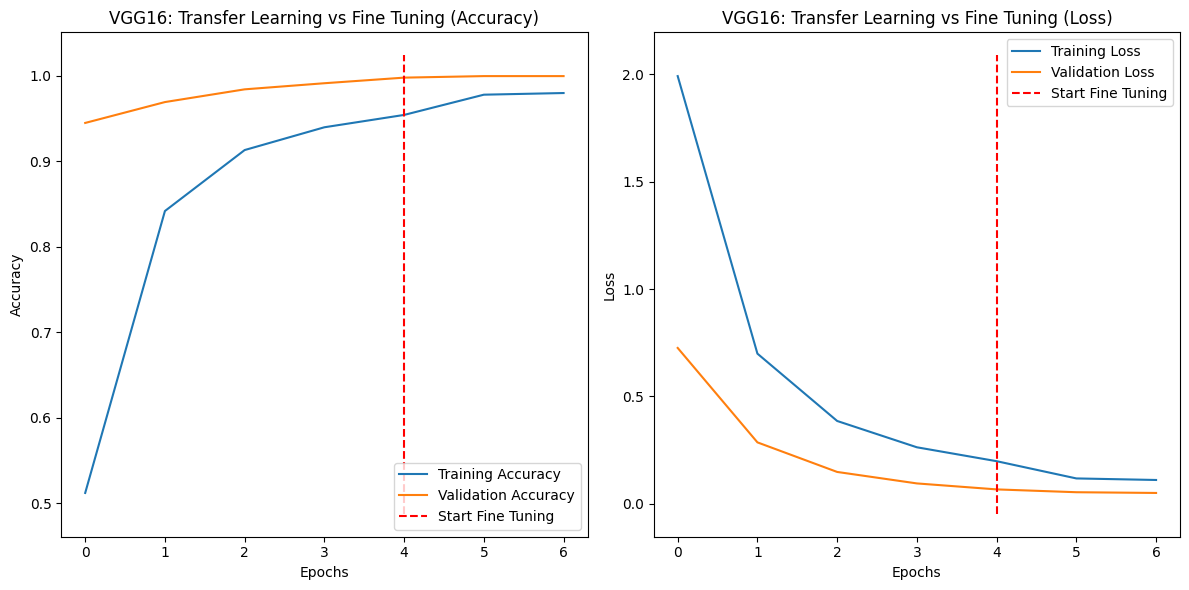

In [20]:
import matplotlib.pyplot as plt

# 1. تجميع نتائج الدقة من المرحلة الأولى والثانية
acc = history_vgg.history['accuracy'] + history_vgg_fine.history['accuracy']
val_acc = history_vgg.history['val_accuracy'] + history_vgg_fine.history['val_accuracy']

# 2. تجميع نتائج الخسارة من المرحلة الأولى والثانية
loss = history_vgg.history['loss'] + history_vgg_fine.history['loss']
val_loss = history_vgg.history['val_loss'] + history_vgg_fine.history['val_loss']

# تحديد عدد الـ epochs للمرحلة الأولى لوضع خط فاصل
initial_epochs = len(history_vgg.history['accuracy'])

# 3. رسم بياني للدقة (Accuracy)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.plot([initial_epochs-1, initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning', color='red', linestyle='--') # الخط الفاصل
plt.title('VGG16: Transfer Learning vs Fine Tuning (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# 4. رسم بياني للخسارة (Loss)
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.plot([initial_epochs-1, initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning', color='red', linestyle='--') # الخط الفاصل
plt.title('VGG16: Transfer Learning vs Fine Tuning (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
📊 تقرير أداء VGG16 النهائي بعد الـ Fine-tuning:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         4
           C       1.00      1.00      1.00         4
           D       1.00      1.00      1.00         4
           E       1.00      1.00      1.00         4
           F       1.00      1.00      1.00         4
           G       1.00      1.00      1.00         4
           H       1.00      1.00      1.00         4
           I       1.00      1.00      1.00         4
           J       1.00      1.00      1.00         4
           K       1.00      1.00      1.00         4
           L       1.00      1.00      1.00         4
           M       1.00      1.00      1.00         4
           N       1.00      1.00      1.00         4
     Nothing       1.00      1.00      1.00         4
           O       1.00      1.00      1.00      

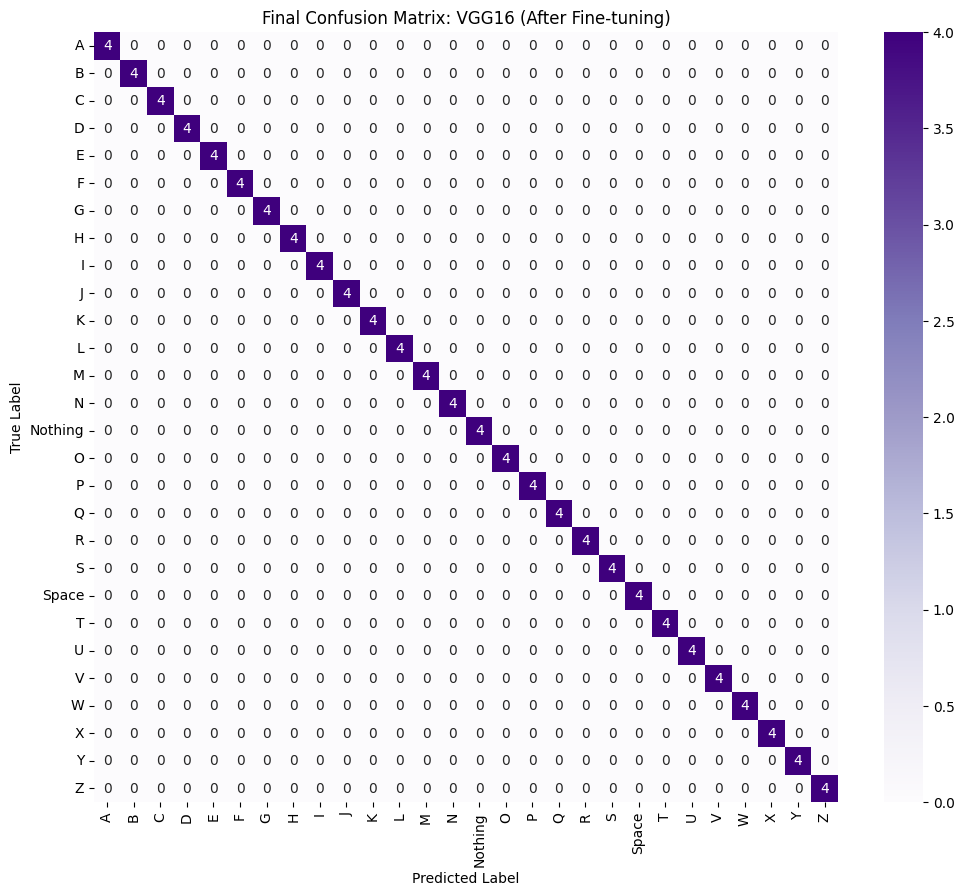

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. التوقع باستخدام النموذج المحدث (بعد الـ Fine-tuning)
y_pred_vgg = model_vgg.predict(X_test_pre)
y_pred_classes_vgg = np.argmax(y_pred_vgg, axis=1)

# 2. طباعة تقرير الأداء النهائي لمقارنة الأرقام
print("📊 تقرير أداء VGG16 النهائي بعد الـ Fine-tuning:")
print(classification_report(y_test_idx, y_pred_classes_vgg, target_names=le.classes_))

# 3. رسم مصفوفة الارتباك
plt.figure(figsize=(12, 10))
cm_vgg = confusion_matrix(y_test_idx, y_pred_classes_vgg)
sns.heatmap(cm_vgg, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Purples')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Final Confusion Matrix: VGG16 (After Fine-tuning)')
plt.show()

In [22]:
from tensorflow.keras.applications import MobileNet

# 1. بناء MobileNet وتجميد الأوزان
base_model_mobile = MobileNet(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
for layer in base_model_mobile.layers:
    layer.trainable = False

# 2. إضافة الطبقات النهائية
x = base_model_mobile.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
predictions_mobile = Dense(len(le.classes_), activation='softmax')(x)

model_mobile = Model(inputs=base_model_mobile.input, outputs=predictions_mobile)
model_mobile.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. التدريب
print("⏳ جاري تدريب MobileNet مع تقنية Data Augmentation...")
history_mobile = model_mobile.fit(
    datagen.flow(X_train_aug, y_train_aug, batch_size=32),
    epochs=5,
    validation_data=(X_val_aug, y_val_aug)
)

/tmp/ipykernel_17233/1312518483.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_mobile = MobileNet(weights='imagenet', include_top=False, input_shape=(96, 96, 3))


⏳ جاري تدريب MobileNet مع تقنية Data Augmentation...
Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 27s 103ms/step - accuracy: 0.9345 - loss: 0.2572 - val_accuracy: 0.9905 - val_loss: 0.0274
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - accuracy: 0.9890 - loss: 0.0381 - val_accuracy: 0.9940 - val_loss: 0.0187
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.9920 - loss: 0.0250 - val_accuracy: 0.9929 - val_loss: 0.0161
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - accuracy: 0.9920 - loss: 0.0258 - val_accuracy: 0.9821 - val_loss: 0.0587
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.9929 - loss: 0.0229 - val_accuracy: 0.9994 - val_loss: 0.0018


In [23]:
from sklearn.metrics import classification_report

# 1. التوقع باستخدام نموذج MobileNet
y_pred_mobile = model_mobile.predict(X_test_pre)
y_pred_classes_mobile = np.argmax(y_pred_mobile, axis=1)

# 2. طباعة تقرير الأداء النهائي
print("📊 تقرير أداء نموذج MobileNet على بيانات الاختبار:")
print(classification_report(y_test_idx, y_pred_classes_mobile, target_names=le.classes_))

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 997ms/step
📊 تقرير أداء نموذج MobileNet على بيانات الاختبار:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         4
           C       1.00      1.00      1.00         4
           D       1.00      1.00      1.00         4
           E       1.00      1.00      1.00         4
           F       1.00      1.00      1.00         4
           G       1.00      1.00      1.00         4
           H       1.00      1.00      1.00         4
           I       1.00      1.00      1.00         4
           J       1.00      1.00      1.00         4
           K       1.00      1.00      1.00         4
           L       1.00      1.00      1.00         4
           M       1.00      1.00      1.00         4
           N       1.00      1.00      1.00         4
     Nothing       1.00      1.00      1.00         4
           O       1.00      1.00      1.00   

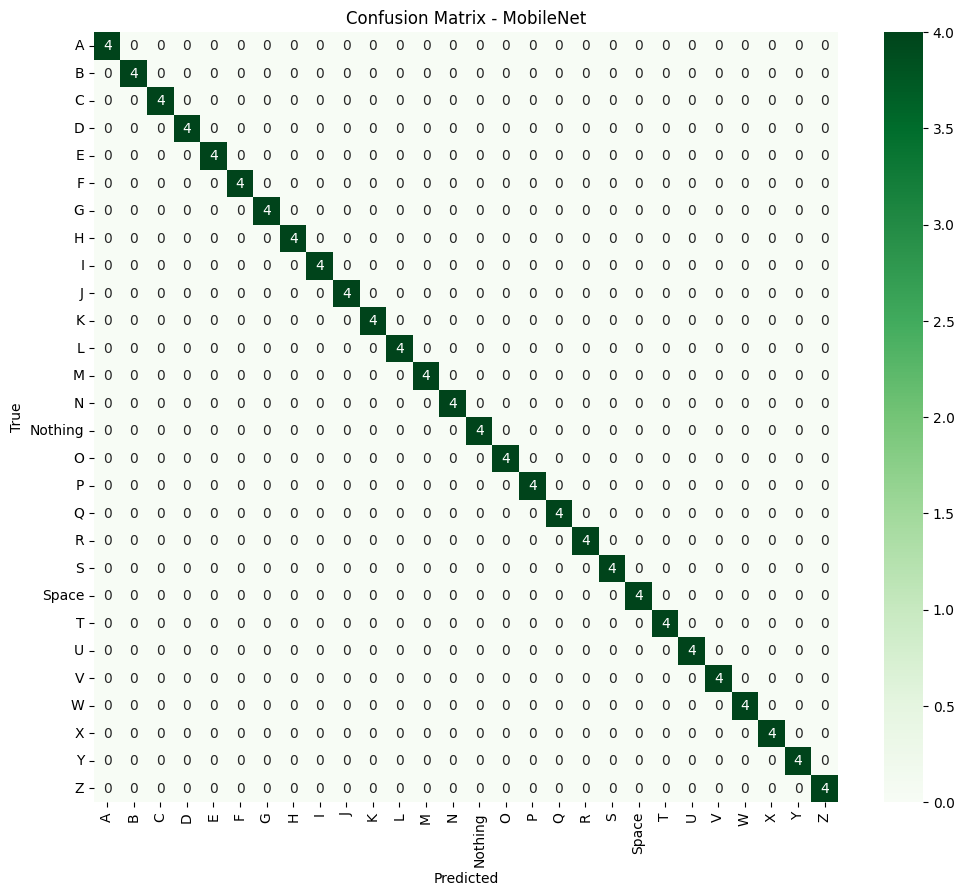

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(12, 10))
cm_mobile = confusion_matrix(y_test_idx, y_pred_classes_mobile)
sns.heatmap(cm_mobile, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - MobileNet')
plt.show()

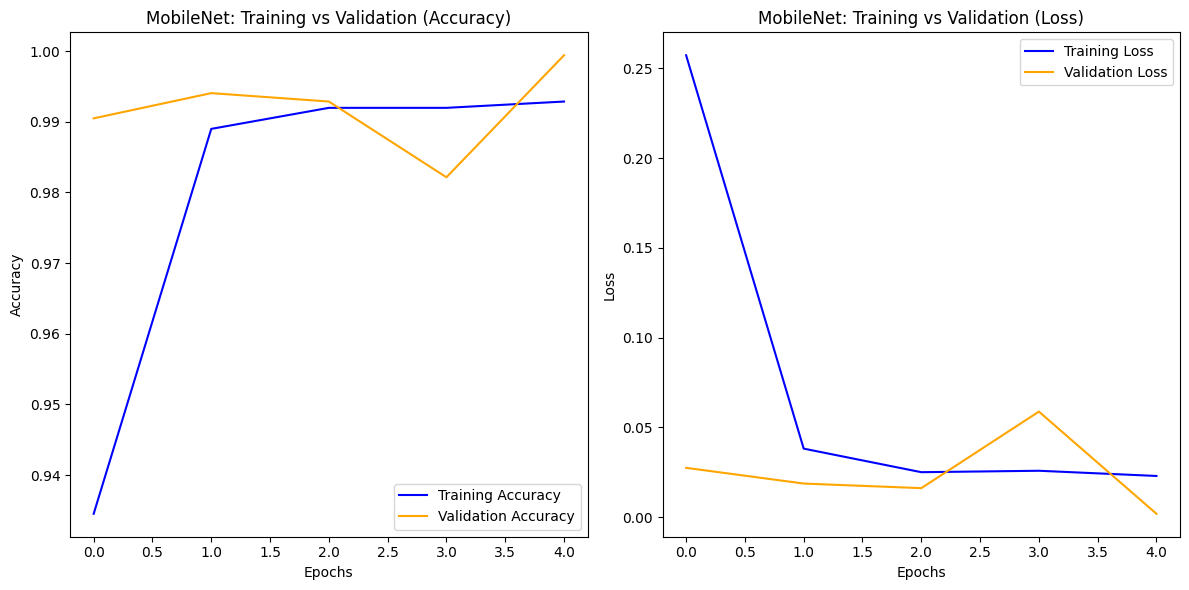

In [26]:
import matplotlib.pyplot as plt

# استخراج بيانات الدقة والخسارة لنموذج MobileNet
acc = history_mobile.history['accuracy']
val_acc = history_mobile.history['val_accuracy']
loss = history_mobile.history['loss']
val_loss = history_mobile.history['val_loss']

# رسم بياني للدقة
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')
plt.title('MobileNet: Training vs Validation (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# رسم بياني للخسارة
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.title('MobileNet: Training vs Validation (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()